In [ ]:
from pymoo.indicators.hv import HV
from scipy.stats import mannwhitneyu

import numpy as np
import pickle
import statistics
import pandas as pd
import matplotlib.pyplot as plt

# Hypervolume:

In [ ]:
# Name of the experiment
experiment_names = ['dtlz1', 'dtlz2', 'dtlz3', 'dtlz4', 'dtlz5', 'dtlz6', 'dtlz7'] # ['wfg1', 'wfg3', 'wfg4', 'wfg5', 'wfg6', 'wfg7', 'wfg8', 'wfg9']
# Choosing the files
choose_global_best_attribution_type = [0] # [0, 1, 2, 3]
choose_Xr_pool_type = [1] # [0, 1, 2]
choose_DE_mutation_type = [0] # [0, 1, 2, 3, 4]
# Consider NSGA-II results
insert_nsga = True
# Create the hypervolume indicator
ref_point = np.array([10]*3)
indicator = HV(ref_point=ref_point)


# Name of chosen files
file_names_mesh = [
        f"E{i+1}V{j+1}D{k+1}_{experiment_name}.pkl"
        for i in choose_global_best_attribution_type
        for j in choose_Xr_pool_type
        for k in choose_DE_mutation_type
        for experiment_name in experiment_names
    ]
# Name of NSGA-II files
file_names_nsga = []
if insert_nsga:
  file_names_nsga.extend(['NSGA2_' + name + '.pkl' for name in experiment_names])

# All files
file_names = file_names_mesh + file_names_nsga
# Number of datasets
num_dataset = len(file_names)

# Take the results
results = []
results_mesh = []
results_nsga = []

for i in range(len(file_names_mesh)):
  with open("../result/" + file_names_mesh[i], "rb") as f:
    results_mesh.append(pickle.load(f))

for i in range(len(file_names_nsga)):
  with open("../result/" + file_names_nsga[i], "rb") as f:
    results_nsga.append(pickle.load(f))
results = results_mesh + results_nsga

# Create the pandas DataFrame columns
columns = ['Algorithm', 'Function', 'Mean HV', 'Std. Dev.', 'Median', 'Combined HV', 'Min. HV', 'Max. HV',]
# Store the datas
data = []
for i, fn in enumerate(file_names):
  HVs = []
  r = results[i]
  for j in range(len(results[i])-1):
    HVs.append(indicator(r[j+1]["F"]))
  if len(HVs) > 1:
    exp = fn.split('_', 1)
    alg = exp[0]
    func = (exp[1].split('.', 1))[0]
    data.append([alg, func.upper(), statistics.mean(HVs), statistics.stdev(HVs), statistics.median(HVs), indicator(results[i]['combined'][1]), min(HVs), max(HVs),])
  else:
    exp = fn.split('_', 1)
    alg = exp[0]
    func = (exp[1].split('.', 1))[0]
    data.append([alg, func.upper(), statistics.mean(HVs), 0, HVs[0], indicator(results[i]['combined'][1]), min(HVs), max(HVs),])

# Create the DataFrame with hypervolume results
df = pd.DataFrame(data, columns=columns)
df

,Algorithm,Function,Mean HV,Std. Dev.,Median,Combined HV,Min. HV,Max. HV
0,E1V2D1,DTLZ1,959.625976,82.563612,994.150408,999.970676,613.985182,999.970129
1,NSGA2,DTLZ1,377.718860,318.475004,310.876960,963.313084,0.000000,945.382681


In [94]:
print(df.to_latex(index=False, float_format="%.3f", escape=False, column_format='lcccccc', label='tab:hv', caption='Hypervolume indicator of the algorithms on the test problems.'))

\begin{table}
\caption{Hypervolume indicator of the algorithms on the test problems.}
\label{tab:hv}
\begin{tabular}{lcccccc}
\toprule
Algorithm & Function & Mean HV & Std. Dev. & Median & Combined HV & Min. HV & Max. HV \\
\midrule
E1V2D1 & ZDT1 & 99.660 & 0.000 & 99.660 & 99.664 & 99.659 & 99.661 \\
E1V2D1 & ZDT2 & 98.395 & 2.846 & 99.328 & 99.330 & 90.000 & 99.328 \\
E1V2D1 & ZDT4 & 67.088 & 33.716 & 88.211 & 99.653 & 0.000 & 99.651 \\
E1V2D1 & ZDT3 & 107.000 & 0.002 & 107.001 & 107.003 & 106.993 & 107.002 \\
E1V2D1 & ZDT6 & 96.795 & 0.000 & 96.795 & 96.797 & 96.794 & 96.795 \\
NSGA2 & ZDT1 & 99.644 & 0.004 & 99.644 & 99.655 & 99.635 & 99.652 \\
NSGA2 & ZDT2 & 99.292 & 0.014 & 99.296 & 99.312 & 99.237 & 99.309 \\
NSGA2 & ZDT4 & 90.581 & 5.090 & 91.856 & 96.884 & 76.101 & 96.749 \\
NSGA2 & ZDT3 & 106.977 & 0.010 & 106.979 & 106.996 & 106.952 & 106.994 \\
NSGA2 & ZDT6 & 95.141 & 0.449 & 95.222 & 95.873 & 94.018 & 95.871 \\
\bottomrule
\end{tabular}
\end{table}



# Teste de Hipóteses - Mann-Whitney U

In [109]:
# Significance level
alpha = 0.05
# Store the groups for the Mann-Whitney U test
results_a = results_mesh
results_b = results_nsga

# Create the pandas DataFrame columns
columns = ['Function', 'p-value', 'Statistic', 'H0', 'Median A', 'Median B', 'Mean A', 'Mean B', 'Std. Dev. A', 'Std. Dev. B']
# Store the datas
test_data = []
for i in range(min(len(results_a), len(results_b))):
  group_a = []
  group_b = []
  for j in range(len(results[i])-1):
    group_a.append(indicator(results_a[i][j+1]["F"]))
    group_b.append(indicator(results_b[i][j+1]["F"]))
  func = experiment_names[i]
  # Perform the Mann-Whitney U test
  stat, p_valor = mannwhitneyu(group_a, group_b, alternative='two-sided')
  test_data.append([func.upper(), p_valor, stat, 'Accepts' if p_valor > alpha else 'Rejects',
                    statistics.median(group_a), statistics.median(group_b),
                    statistics.mean(group_a), statistics.mean(group_b),
                    statistics.stdev(group_a), statistics.stdev(group_b)])

# Create the DataFrame for the Mann-Whitney U test results
df_statistic = pd.DataFrame(test_data, columns=columns)
df_statistic

,Function,p-value,Statistic,H0,Median A,Median B,Mean A,Mean B,Std. Dev. A,Std. Dev. B
0,DTLZ1,2.366060e-10,879.0,Rejects,994.150408,310.87696,959.625976,377.71886,82.563612,318.475004


# Hypervolume Boxplot:

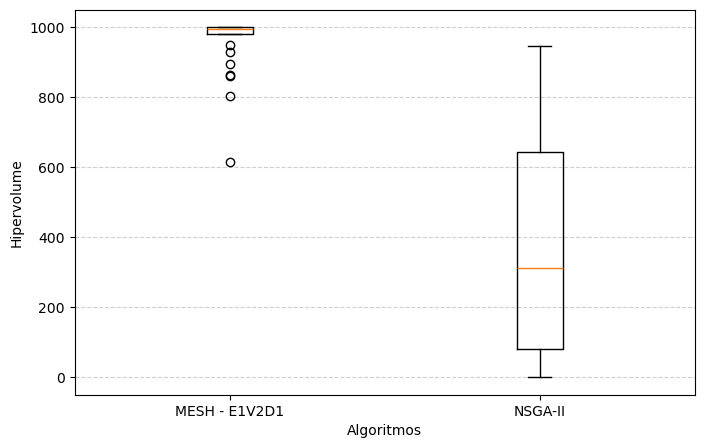

In [108]:
# Experiment name
experiment_name = 'dtlz1'
# Choosing the files
choose_global_best_attribution_type = [0] # [0, 1, 2, 3]
choose_Xr_pool_type = [1] # [0, 1, 2]
choose_DE_mutation_type = [0] # [0, 1, 2, 3, 4]
# Consider NSGA-II results
insert_nsga = True


# Name of chosen files
file_names_mesh = [
        f"E{i+1}V{j+1}D{k+1}_{experiment_name}.pkl"
        for i in choose_global_best_attribution_type
        for j in choose_Xr_pool_type
        for k in choose_DE_mutation_type
    ]
# Name of NSGA-II files
file_names_nsga = []
if insert_nsga:
  file_names_nsga.extend(['NSGA2_' + experiment_name + '.pkl'])

# Take the results
results_mesh = []
results_nsga = []
for i in range(len(file_names_mesh)):
  with open("../result/" + file_names_mesh[i], "rb") as f:
    results_mesh.append(pickle.load(f))
for i in range(len(file_names_nsga)):
  with open("../result/" + file_names_nsga[i], "rb") as f:
    results_nsga.append(pickle.load(f))

# Get MESH hypervolumes
data = []
for i, fn in enumerate(file_names_mesh):
  HVs = []
  r = results_mesh[i]
  for j in range(len(results_mesh[i])-1):
    HVs.append(indicator(r[j+1]["F"]))
  data.append(HVs)
# Get NSGA-II hypervolumes if applicable
for i in range(len(file_names_nsga)):
  HVs = []
  r = results_nsga[i]
  for j in range(len(results_nsga[i])-1):
    HVs.append(indicator(r[j+1]["F"]))
  data.append(HVs)

# Creating a boxplot
labels = ['MESH - ' + fn.split('_', 1)[0] for fn in file_names_mesh] + (['NSGA-II'] if insert_nsga else [])
plt.figure(figsize=(8, 5))
plt.boxplot(data, tick_labels=labels, showmeans=False)

# Titles and labels
# plt.title('Hypervolume - ' + experiment_name.upper(), fontsize=14)
plt.xlabel('Algoritmos') # plt.xlabel('Algorithms')
plt.ylabel('Hipervolume') # plt.ylabel('Hypervolume')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()